# XGBoost Fraud Detection – Teaching Notebook

## Lernziele

In diesem Notebook lernen Studierende:

- warum Fraud Detection ein schwieriges ML-Problem ist
- was Klassenimbalance bedeutet
- warum Accuracy oft ungeeignet ist
- wie Gradient Boosting funktioniert
- wie man mit XGBoost ein leistungsfähiges Klassifikationsmodell trainiert
- wie man Precision, Recall, F1 und ROC-AUC interpretiert
- wie man Feature Importance analysiert


# 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier


# 2. Datensatz laden

Datensatz:

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


Die Daten enthalten:

anonymisierte PCA-Features V1–V2

Time

Amount

Zielvariable Class








In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [5]:
import os

# Construct the full path to the CSV file
file_path = os.path.join(path, "creditcard.csv")

df = pd.read_csv(file_path)

# 3. Erste Exploration

In [6]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [7]:
print(df.shape)

(284807, 31)


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Klassenverteilung

In [9]:
class_counts = df["Class"].value_counts()
print(class_counts)


Class
0    284315
1       492
Name: count, dtype: int64


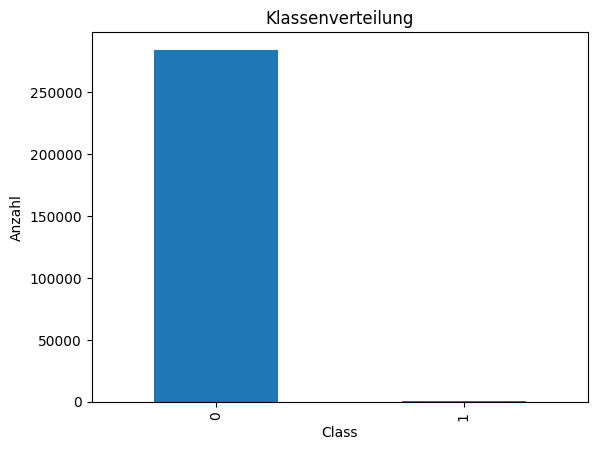

In [10]:
class_counts.plot(kind="bar")
plt.title("Klassenverteilung")
plt.xlabel("Class")
plt.ylabel("Anzahl")
plt.show()


## Beobachtung

Der Datensatz ist extrem unausgeglichen:

- sehr viele legitime Transaktionen
- sehr wenige Fraud-Fälle

Das nennt man:

> Class Imbalance


# 4. Warum Accuracy problematisch ist

Wenn 99.8 % aller Transaktionen legitim sind:

Ein Modell könnte einfach immer 'kein Betrug' vorhersagen.

Dann hätte es:

```text
Accuracy ≈ 99.8 %
```

Aber die Fraud Detection wäre praktisch nutzlos.


# 5. Features und Labels

In [11]:
X = df.drop("Class", axis=1)
y = df["Class"]


# 6. Train/Test-Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 7. Klassenverhältnis berechnen

In [13]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)


577.2868020304569


# 8. XGBoost-Modell

In [14]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)


# 9. Modell trainieren

In [15]:
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

# 10. Vorhersagen

In [16]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


# 11. Evaluation

In [17]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.87      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [18]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[56809    55]
 [   13    85]]


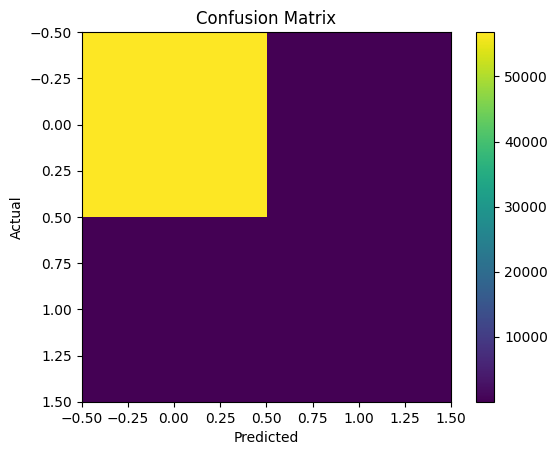

In [19]:
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 12. ROC-AUC

In [20]:
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)


ROC-AUC: 0.9795035487464541


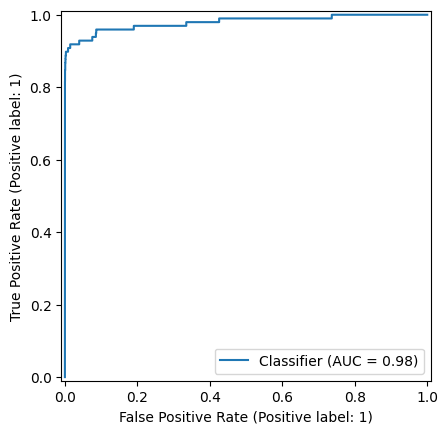

In [21]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()


# 13. Precision-Recall-Kurve

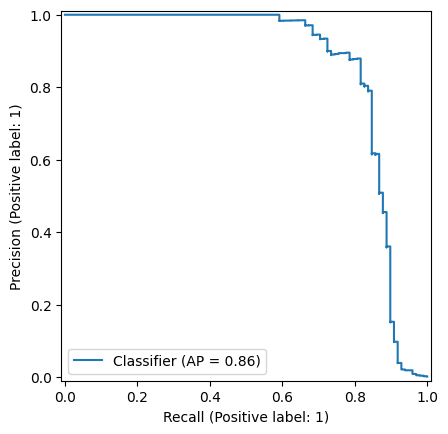

In [22]:
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.show()


# 14. Feature Importance

In [23]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))


   Feature  Importance
14     V14    0.322876
4       V4    0.106713
10     V10    0.061790
20     V20    0.037016
17     V17    0.032462
8       V8    0.032402
29  Amount    0.027928
12     V12    0.027080
7       V7    0.024641
11     V11    0.023316


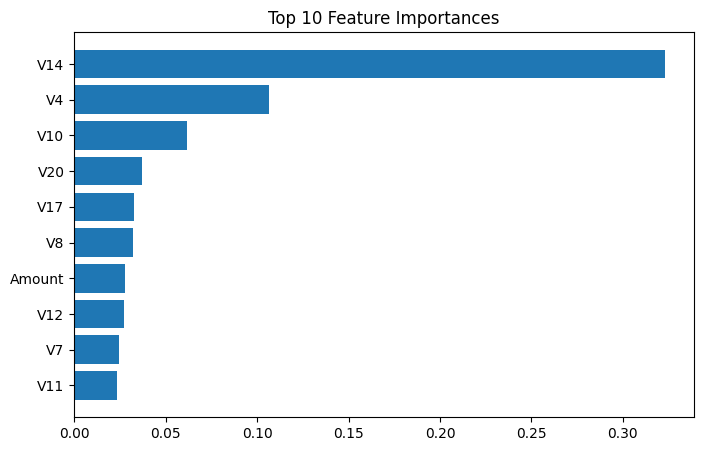

In [24]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()


# 15. Übungen

## Aufgabe 1

Ändere:

```python
max_depth
```

Teste:
- depth = 2
- depth = 10

---

## Aufgabe 2

Experimentiere mit:

```python
learning_rate
```

---

## Aufgabe 3

Vergleiche XGBoost mit:

```python
LogisticRegression
```

---

## Aufgabe 4

Passe den Decision Threshold an:

```python
0.5
0.3
0.1
```


# 16. Bonus: SHAP

In [25]:
# pip install shap

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)


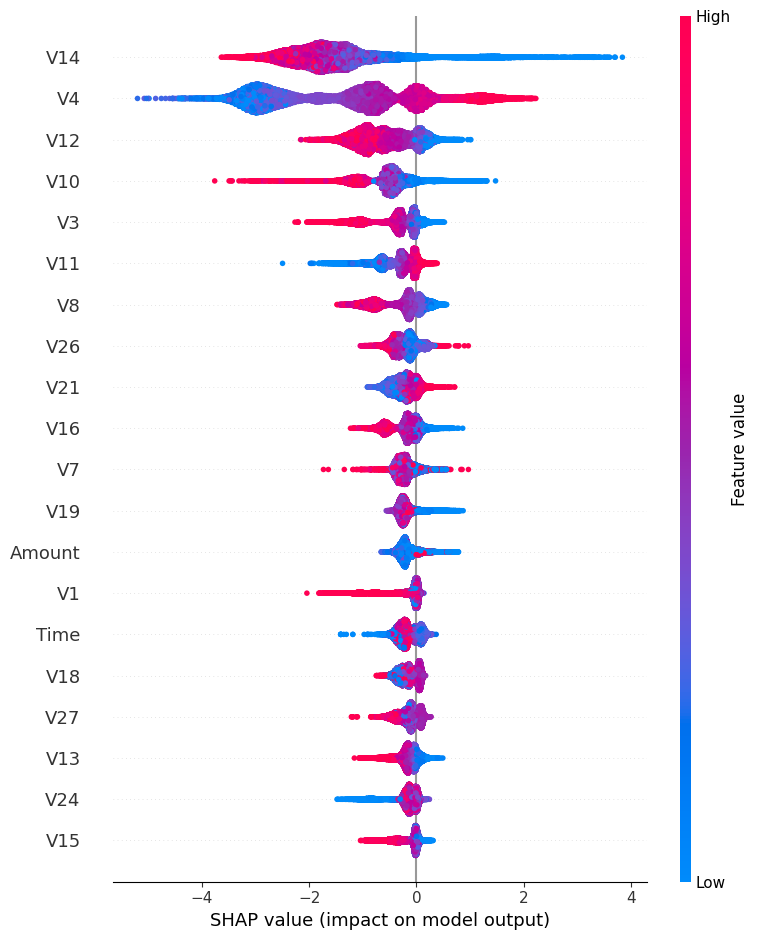

In [26]:
shap.summary_plot(shap_values, X_test)
